In [1]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
(xtrain,ytrain),(xtest,ytest) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1859s 11us/step


In [2]:
xtrain.shape

(50000, 32, 32, 3)

In [3]:
xtest.shape

(10000, 32, 32, 3)

In [5]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def plot_sample(x, y, index):
    plt.figure(figsize=(14, 2))
    plt.imshow(x[index])
    plt.xlabel(classes[y[index][0]])

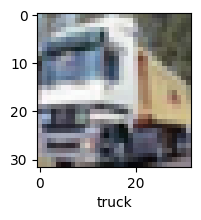

In [6]:
plot_sample(xtrain,ytrain,1)

In [7]:
#Normalize
xtrain = xtrain/255
xtest = xtest/255

In [10]:
#model
cnn = models.Sequential([
#feature extraction
layers.Conv2D(filters=32,activation='relu',kernel_size =
(3,3),input_shape=(32,32,3)),
layers.MaxPooling2D((2,2)),
layers.Conv2D(filters=64,activation='relu',kernel_size =
(3,3),input_shape =(32,32,3)),
layers.MaxPooling2D((2,2)),
#classification
layers.Flatten(),
layers.Dense(64,activation='relu'),
layers.Dense(10,activation='softmax')
])

In [13]:
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.fit(xtrain, ytrain, epochs=20)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 45ms/step - accuracy: 0.4756 - loss: 1.4579
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6116 - loss: 1.1064
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6648 - loss: 0.9641
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.6947 - loss: 0.8754
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.7218 - loss: 0.7979
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7426 - loss: 0.7413
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.7604 - loss: 0.6863
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.7752 - loss: 0.6424
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 40ms/step - accuracy: 0.7887 - loss: 0.6015
Epoch 10/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.8012 - loss: 0.5629
Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.8131 - loss: 0.5300
Epoch 12

In [15]:
ypred = cnn.predict(xtest)
cnn.evaluate(xtest, ytest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6899 - loss: 1.3767


[1.3767348527908325, 0.6898999810218811]

In [16]:
ytest=ytest.reshape(-1,)
ypred=cnn.predict(xtest)
yclasses=[np.argmax(element) for element in ypred]
print('classification report:\
n',classification_report(ytest,yclasses))

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step
classification report:n               precision    recall  f1-score   support

           0       0.73      0.73      0.73      1000
           1       0.80      0.84      0.82      1000
           2       0.59      0.56      0.57      1000
           3       0.52      0.48      0.50      1000
           4       0.61      0.66      0.64      1000
           5       0.58      0.61      0.60      1000
           6       0.79      0.71      0.75      1000
           7       0.74      0.74      0.74      1000
           8       0.77      0.79      0.78      1000
           9       0.76      0.77      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000

